In [1]:
# !pip install dtreeviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 3.1 MB/s eta 0:00:00


In [36]:
import graphviz.backend as be

In [37]:
from sklearn.datasets import *
from dtreeviz.trees import *
from sklearn.tree import *
from IPython.display import Image, display_svg, SVG
from sklearn.tree import export_graphviz

In [4]:
clas = DecisionTreeClassifier(max_depth=5)
iris = load_iris()

x_train = iris.data
y_train = iris.target

clas.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5)

[Text(0.5, 0.9166666666666666, 'x[3] <= 0.8\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]'),
 Text(0.4230769230769231, 0.75, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]'),
 Text(0.46153846153846156, 0.8333333333333333, 'True  '),
 Text(0.5769230769230769, 0.75, 'x[3] <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]'),
 Text(0.5384615384615384, 0.8333333333333333, '  False'),
 Text(0.3076923076923077, 0.5833333333333334, 'x[2] <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]'),
 Text(0.15384615384615385, 0.4166666666666667, 'x[3] <= 1.65\ngini = 0.041\nsamples = 48\nvalue = [0, 47, 1]'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 47\nvalue = [0, 47, 0]'),
 Text(0.23076923076923078, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.46153846153846156, 0.4166666666666667, 'x[3] <= 1.55\ngini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.38461538461538464, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.5384615384615384, 0.25, '

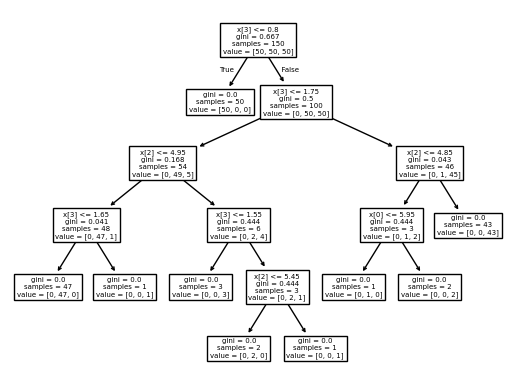

In [5]:
from sklearn.tree import plot_tree
plot_tree(clas)

making the tree

In [6]:
import dtreeviz

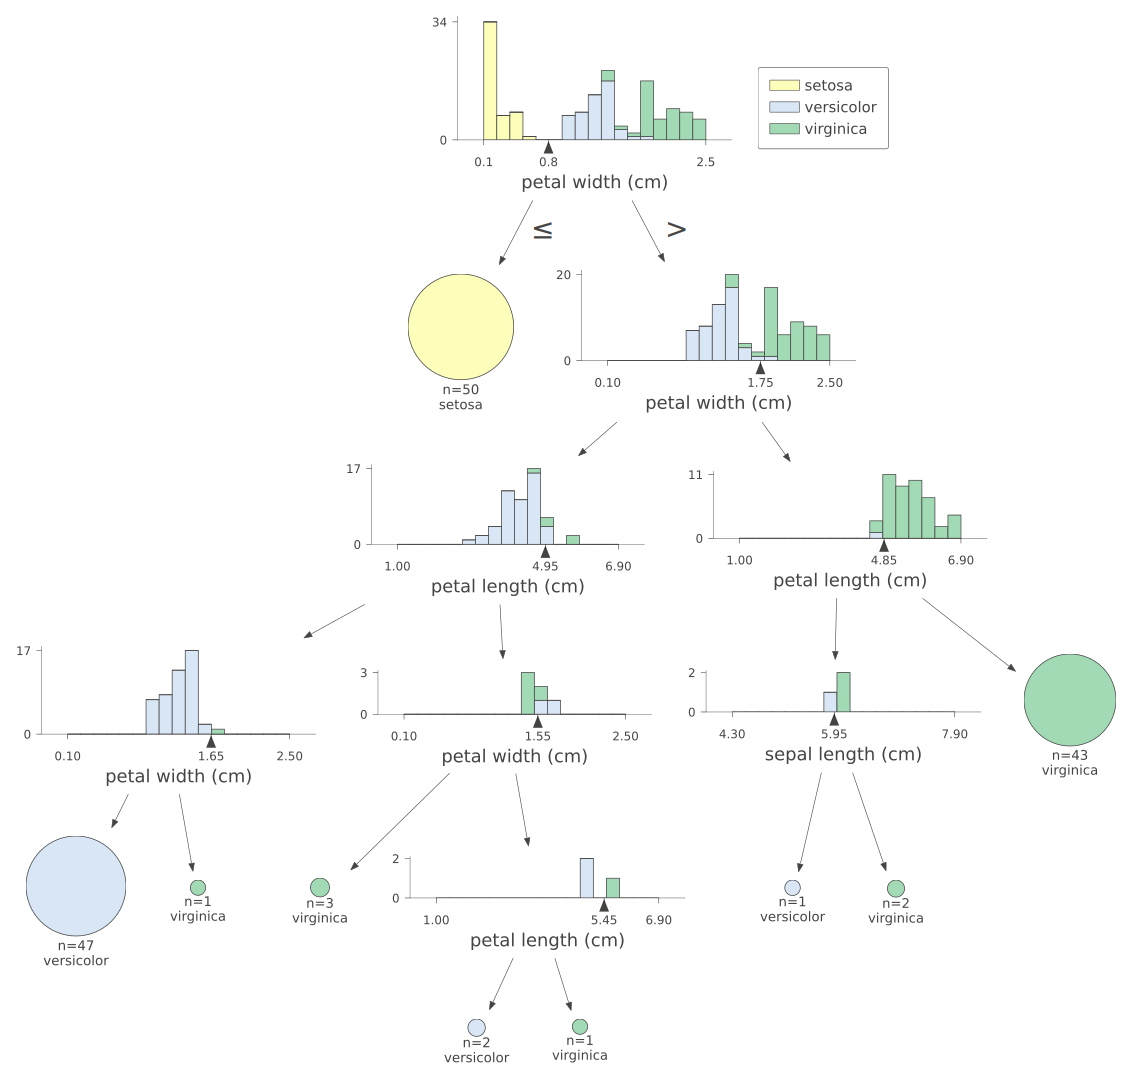

In [7]:
m = dtreeviz.model(
    clas,
    x_train,
    y_train,
    feature_names=iris.feature_names,
    class_names=list(iris.target_names)
)
viz = m.view(fontname='DejaVu Sans', scale=2)
display(viz)

For regression

In [8]:
from sklearn.tree import DecisionTreeRegressor

In [9]:
reg = DecisionTreeRegressor(max_depth=5)
data = load_breast_cancer()

x_train = data.data
y_train = data.target

reg.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=5)

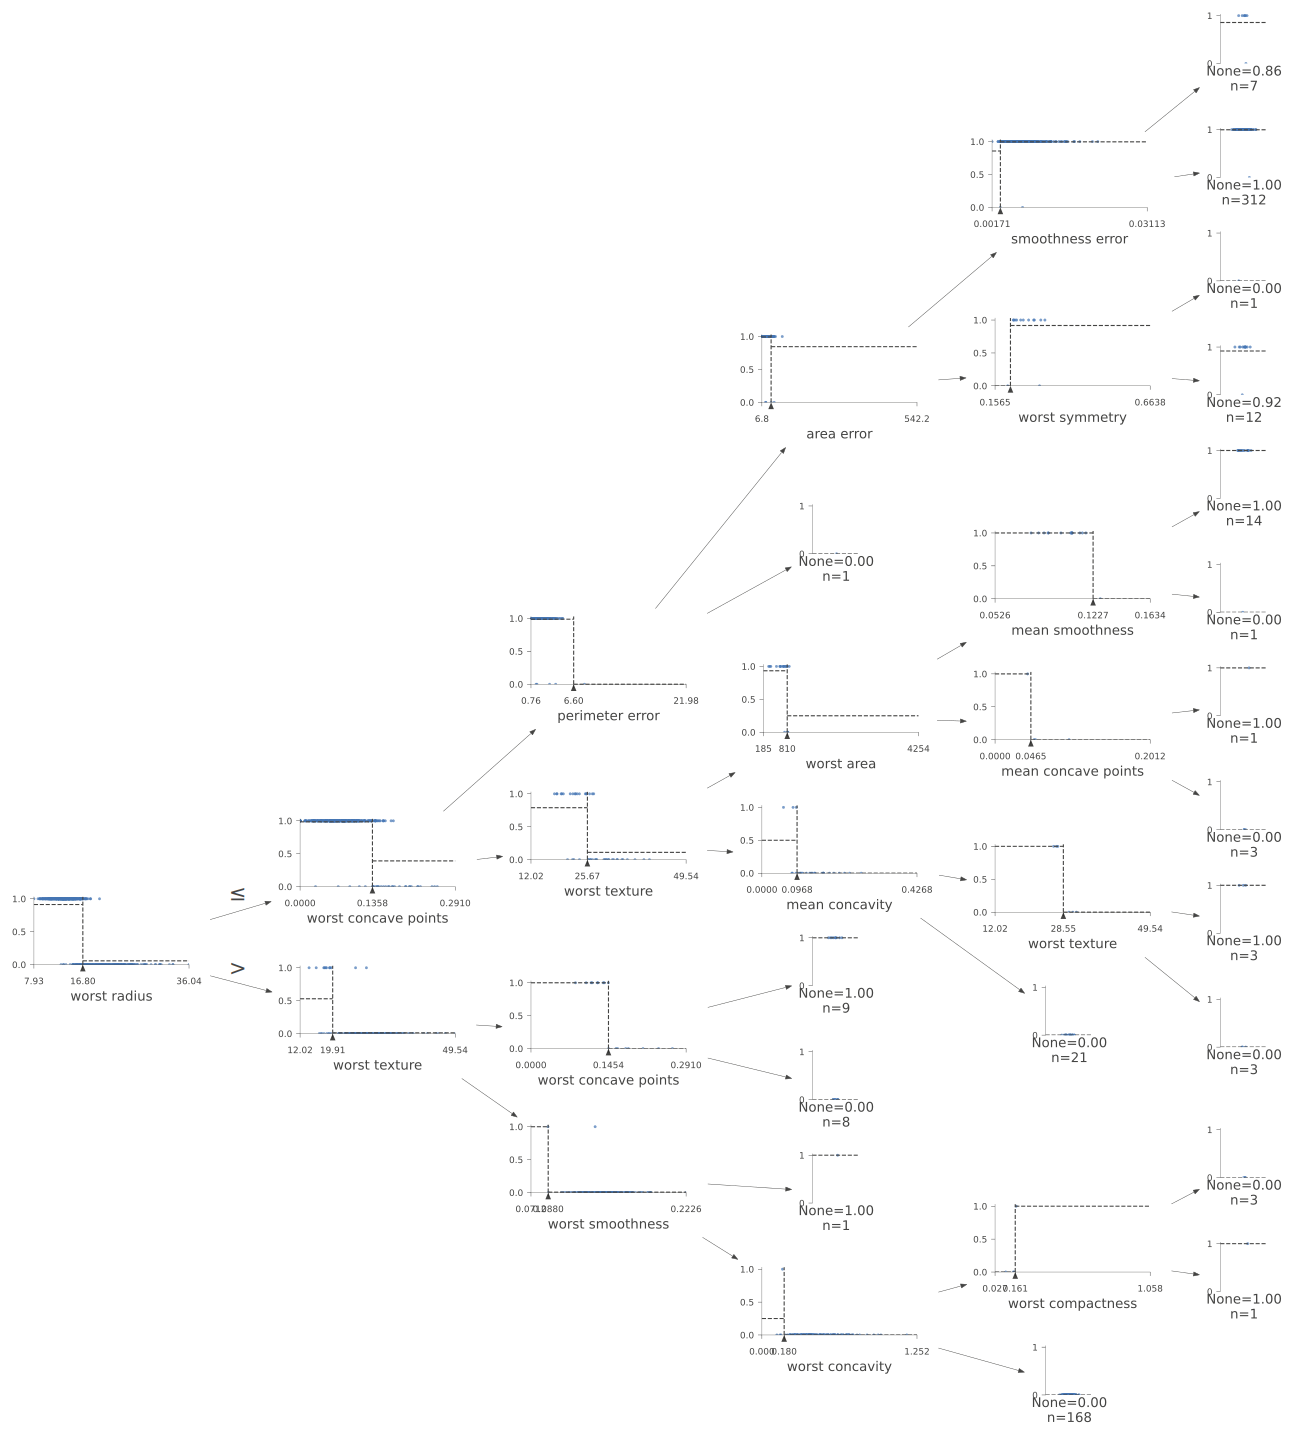

In [10]:


m = dtreeviz.model(
    reg,
    x_train,
    y_train,
    feature_names=data.feature_names,
    class_names=list(data.target_names)
)

viz = m.view(fontname='DejaVu Sans', scale=1.5, orientation='LR')
display(viz)

Path finding

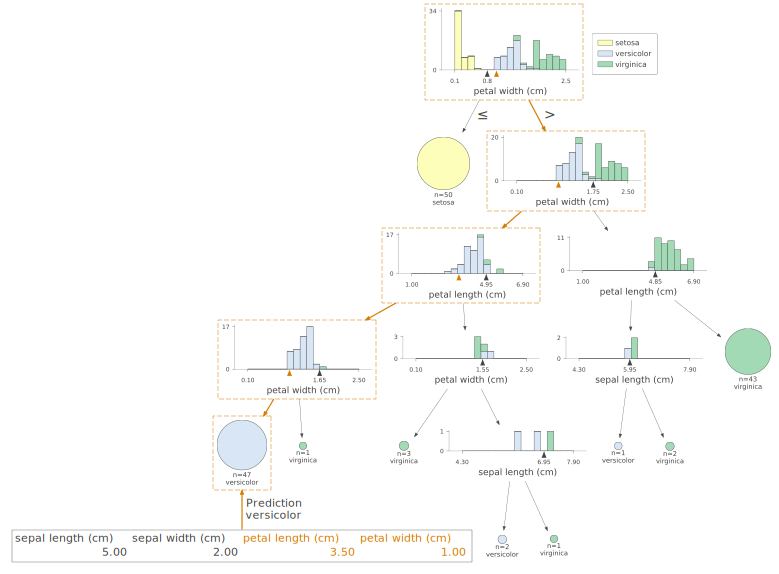

In [11]:
clas = DecisionTreeClassifier(max_depth=5)
iris = load_iris()

x_train = iris.data
y_train = iris.target

clas.fit(x_train, y_train)

x = iris.data[np.random.randint(0, len(iris.data)),:]

m = dtreeviz.model(
    clas,
    x_train,
    y_train,
    feature_names=iris.feature_names,
    class_names=list(iris.target_names),

)
viz = m.view(fontname='DejaVu Sans', scale=1,x=x)
display(viz)

In [12]:
x

array([5. , 2. , 3.5, 1. ])

3D cuts visualization

In [19]:
import pandas as pd
import numpy as np

In [20]:
from mpl_toolkits.mplot3d import Axes3D

In [22]:
clas = DecisionTreeClassifier(max_depth=5)
iris = load_iris()

x_train = iris.data
y_train = iris.target



In [28]:
x_train = pd.DataFrame(x_train, columns=iris.feature_names)
y_train = pd.DataFrame(y_train, columns=['target'])

In [29]:
x_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [30]:
x_train = x_train[['sepal width (cm)', 'petal width (cm)']]

In [31]:
x_train

,sepal width (cm),petal width (cm)
0,3.5,0.2
1,3.0,0.2
2,3.2,0.2
3,3.1,0.2
4,3.6,0.2
...,...,...
145,3.0,2.3
146,2.5,1.9
147,3.0,2.0
148,3.4,2.3


In [32]:
y_train

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [33]:
clas.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


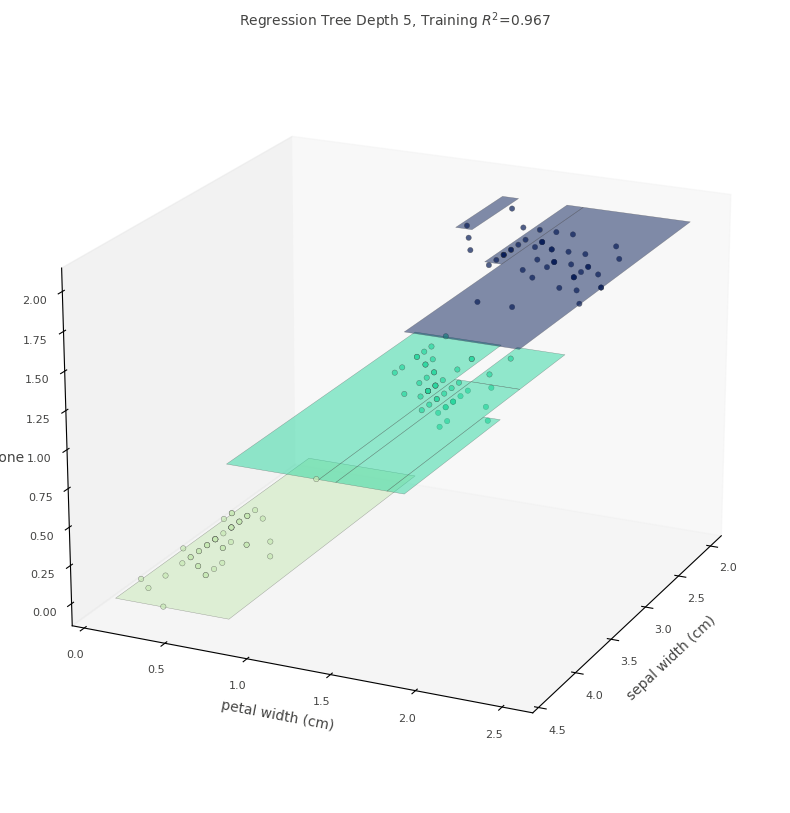

In [54]:
m = dtreeviz.model(
    clas,
    x_train,
    y_train.values.ravel(), # Ensuring y_train is a 1D array of numerical values
    feature_names=x_train.columns.tolist(), # x_train already has only the two desired columns
    class_names=list(iris.target_names)
        )

# Calling the rtree_feature_space3D method directly on the model object
viz = m.rtree_feature_space3D(
    elev= 20,
    azim = 25,
    dist=10,
    show = {'splits', 'title'},
    fontname='DejaVu Sans',
    figsize=(10,10),
       )
